In [1]:
import sys
sys.path.append('../onitama/')
from trainer import RegularDataTrainer
from dl_players_v10 import DensePlayer_v10
import numpy as np
from livelossplot import PlotLossesKeras
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-04-07 18:25:12.561196: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-07 18:25:12.574095: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 18:25:13.142772: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 18:25:15.067392: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

In [5]:
#Configuration

folder_data = "../data/v6b/"

In [6]:
def action_to_one_hot(action, shape=(5, 5, 52)):
    """
    Convertit une action [col, ligne, action_id] en one-hot tensor
    
    Args:
        action: [col, ligne, action_id] ou liste d'actions (batch)
        shape: (height, width, n_actions)
        
    Returns:
        one_hot: (5, 5, 52) ou (batch, 5, 5, 52)
    """
    if isinstance(action, list) and len(action) == 3:
        # Une seule action
        col, ligne, action_id = action
        one_hot = np.zeros(shape, dtype=np.float32)
        one_hot[col, ligne, action_id] = 1.0
        return one_hot
    else:
        # Batch d'actions
        batch_size = len(action)
        one_hot_batch = np.zeros((batch_size, *shape), dtype=np.float32)
        
        for i, act in enumerate(action):
            col, ligne, action_id = act
            one_hot_batch[i, col, ligne, action_id] = 1.0
        
        return one_hot_batch

def flat_index_to_action(flat_index):
    """
    Convertit index flat [0, 1299] en [col, ligne, move_id]
    """
    col = flat_index // (5 * 52)
    ligne = (flat_index // 52) % 5
    move_id = flat_index % 52
    return col, ligne, move_id


def decode_flat_policy(flat_policy):
    """
    Décode un vecteur aplati (1300,) en [col, ligne, move_id]
    
    Args:
        flat_policy: array de shape (1300,) - one-hot ou probabilités
        
    Returns:
        action: [col, ligne, move_id]
    """
    # 1. Trouver l'index du maximum (ou du 1.0 si one-hot)
    best_index = np.argmax(flat_policy)
    
    # 2. Décoder l'index
    col = best_index // (5 * 52)
    ligne = (best_index // 52) % 5
    move_id = best_index % 52
    
    return [int(col), int(ligne), int(move_id)]

def old_one_hot_to_action(action, verbose=False):
    """
    Convertit un one-hot tensor en action [col, ligne, move_id]
    
    Args:
        action: (5, 5, 52) ou (batch, 5, 5, 52)
        verbose: afficher les détails
        
    Returns:
        (col, ligne, move_id) ou liste de (col, ligne, move_id)
    """
    action = np.array(action)
    
    # Déterminer si c'est un batch ou une action seule
    if action.ndim == 3:
        # Une seule action (5, 5, 52)
        flat_logits = action.reshape(-1)
        
        exp_logits = np.exp(flat_logits - np.max(flat_logits))
        probabilities = exp_logits / exp_logits.sum()
        
        best_flat = np.argmax(probabilities)
        best_col, best_ligne, best_move_id = flat_index_to_action(best_flat)
        
        if verbose:
            print(f"Probabilités : {probabilities.shape}, sum={probabilities.sum():.3f}")
            print(f"Meilleure action : [{best_col}, {best_ligne}, {best_move_id}]")
            print(f"Probabilité : {probabilities[best_flat]:.4f}")
        
        return (best_col, best_ligne, best_move_id)
    
    elif action.ndim == 4:
        # Batch d'actions (batch, 5, 5, 52)
        batch_size = action.shape[0]
        results = []
        
        for i in range(batch_size):
            flat_logits = action[i].reshape(-1)
            
            exp_logits = np.exp(flat_logits - np.max(flat_logits))
            probabilities = exp_logits / exp_logits.sum()
            
            best_flat = np.argmax(probabilities)
            best_col, best_ligne, best_move_id = flat_index_to_action(best_flat)
            
            if verbose:
                print(f"[{i}] Probabilités : {probabilities.shape}, sum={probabilities.sum():.3f}")
                print(f"[{i}] Meilleure action : [{best_col}, {best_ligne}, {best_move_id}]")
                print(f"[{i}] Probabilité : {probabilities[best_flat]:.4f}")
            
            results.append((best_col, best_ligne, best_move_id))
        
        return results
    
    else:
        raise ValueError(f"Action doit avoir 3 ou 4 dimensions, reçu {action.ndim}")

In [7]:
#Récupération des données
import glob
import os


# Scanner le dossier et grouper par préfixe (nom de base sans suffixe)
states_files = sorted(glob.glob(os.path.join(folder_data, "*.states.pkl")))
basenames = [os.path.basename(f).replace(".states.pkl", "") for f in states_files]

policy_files = [os.path.join(folder_data, f"{b}.labels.pkl") for b in basenames]
mask_files   = [os.path.join(folder_data, f"{b}.mask.pkl")   for b in basenames]

# Vérifier que tous les fichiers existent
for s, p, m in zip(states_files, policy_files, mask_files):
    for path in [s, p, m]:
        if not os.path.exists(path):
            print(f"⚠️  Fichier manquant : {path}")

print(f"{len(basenames)} jeu(x) de données trouvé(s) :")
for b in basenames:
    print(f"  - {b}")

states = []
policies = []
masks = []

for s_file, p_file, m_file in zip(states_files, policy_files, mask_files):
    states   += RegularDataTrainer.getTrainedData(filepath=s_file)
    policies += RegularDataTrainer.getTrainedData(filepath=p_file)
    masks    += RegularDataTrainer.getTrainedData(filepath=m_file)
    print(f"Chargé : {os.path.basename(s_file)}")

print("\n\nTotal :")
print(f"{len(states)} states")
print(f"{len(policies)} policies")
print(f"{len(masks)} masks")
print(f"{len(policies) / 21} games (approx.)")

# Filtrer les entrées dont le state n'a pas la shape attendue (10, 5, 5)
EXPECTED_SHAPE = (10, 5, 5)
valid = [np.array(s).shape == EXPECTED_SHAPE for s in states]
n_invalid = sum(1 for v in valid if not v)
if n_invalid > 0:
    print(f"⚠️  {n_invalid} états ignorés (shape incorrecte)")
    states   = [s for s, v in zip(states,   valid) if v]
    policies = [p for p, v in zip(policies, valid) if v]
    masks    = [m for m, v in zip(masks,    valid) if v]

states = np.array(states)
print(states.shape)

#On est en (10, 5, 5) le réseau attend du (5, 5, 10) il faut transposer
states = np.transpose(states, (0, 2, 3, 1))
print(states.shape) #Maintenant on est bien (en 5,5,10)

6 jeu(x) de données trouvé(s) :
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_positional
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_regular
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive.states.pkl
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-Look

In [8]:

#On applique one Hot Encoder sur les actions (policies)
policies = action_to_one_hot(policies)




In [9]:

#Aplatir pour correspondre à la sortie du modèle
policies = policies.reshape(-1, 5 * 5 * 52)  # (batch, 1300)




In [10]:
#Concatner avec les masques
masks = np.array(masks, dtype=np.float32)
y_masked = np.concatenate([policies, masks], axis=1)

In [11]:
# Fix: shuffle en place AVANT validation_split (sans copie mémoire)
# np.random.permutation + fancy indexing crée des copies → OOM sur gros datasets
# Ici on utilise le même RNG avec le même seed pour shuffler les deux tableaux identiquement
seed = np.random.randint(0, 2**31)
rng = np.random.default_rng(seed)
rng.shuffle(states)      # shuffle en place (axe 0)
rng = np.random.default_rng(seed)
rng.shuffle(y_masked)    # même permutation, en place
print(f"Données mélangées : {len(states)} échantillons")

Données mélangées : 474458 échantillons


In [12]:
policies[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1300,), dtype=float32)

In [13]:
network = DensePlayer_v10()


2026-04-07 15:22:59.411930: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [14]:
# Compiler pour supervised (gèle value head - spécifier d'utiliser les masques pour le calcul de la loss)
network.compile_for_supervised_policy(use_mask=True)

Gelé 3 layers de la tête de valeur
Modèle compilé pour entraînement supervisé (policy seulement, label_smoothing=0.0, weight_decay=0.0001, use_mask=True)


In [15]:
network.summary()

Model: "OnitamaNetwork-v10-Dense"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state_input         │ (None, 5, 5, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_flatten       │ (None, 250)       │          0 │ state_input[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_0       │ (None, 128)       │     32,128 │ trunk_flatten[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_0        │ (None, 128)       │          0 │ trunk_dense_0[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_1       │ (None, 128)       │     16,512 │ trunk_relu_0[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_1        │ (None, 128)       │          0 │ trunk_dense_1[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_skip_add      │ (None, 128)       │          0 │ trunk_relu_1[0][… │
│ (Add)               │                   │            │ trunk_relu_0[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_2       │ (None, 64)        │      8,256 │ trunk_skip_add[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_2        │ (None, 64)        │          0 │ trunk_dense_2[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value_dense1        │ (None, 64)        │      4,160 │ trunk_relu_2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ policy_hidden       │ (None, 64)        │      4,160 │ trunk_relu_2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value_dense2        │ (None, 32)        │      2,080 │ value_dense1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ policy_logits       │ (None, 1300)      │     84,500 │ policy_hidden[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value_output        │ (None, 1)         │         33 │ value_dense2[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 151,829 (593.08 KB)

 Trainable params: 145,556 (568.58 KB)

 Non-trainable params: 6,273 (24.50 KB)

In [16]:
x_train  = states
y_value  = np.zeros((len(x_train), 1))

In [17]:
y_policy = y_masked[:, :1300]  # conserver séparément pour les évaluations top-k

In [18]:
# Fix: aligner EarlyStopping et ModelCheckpoint sur la même métrique.
# Avant : EarlyStopping surveillait val_loss, ModelCheckpoint surveillait val_policy_logits_accuracy.
# Risque : EarlyStopping pouvait arrêter alors que l'accuracy progressait encore.
early_stop = EarlyStopping(
    monitor='val_policy_logits_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

checkpoint = ModelCheckpoint(
    filepath="../saved-models/DensePlayer-v10-best.weights.h5",
    monitor='val_policy_logits_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_policy_logits_accuracy',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    mode='max',
    verbose=1
)

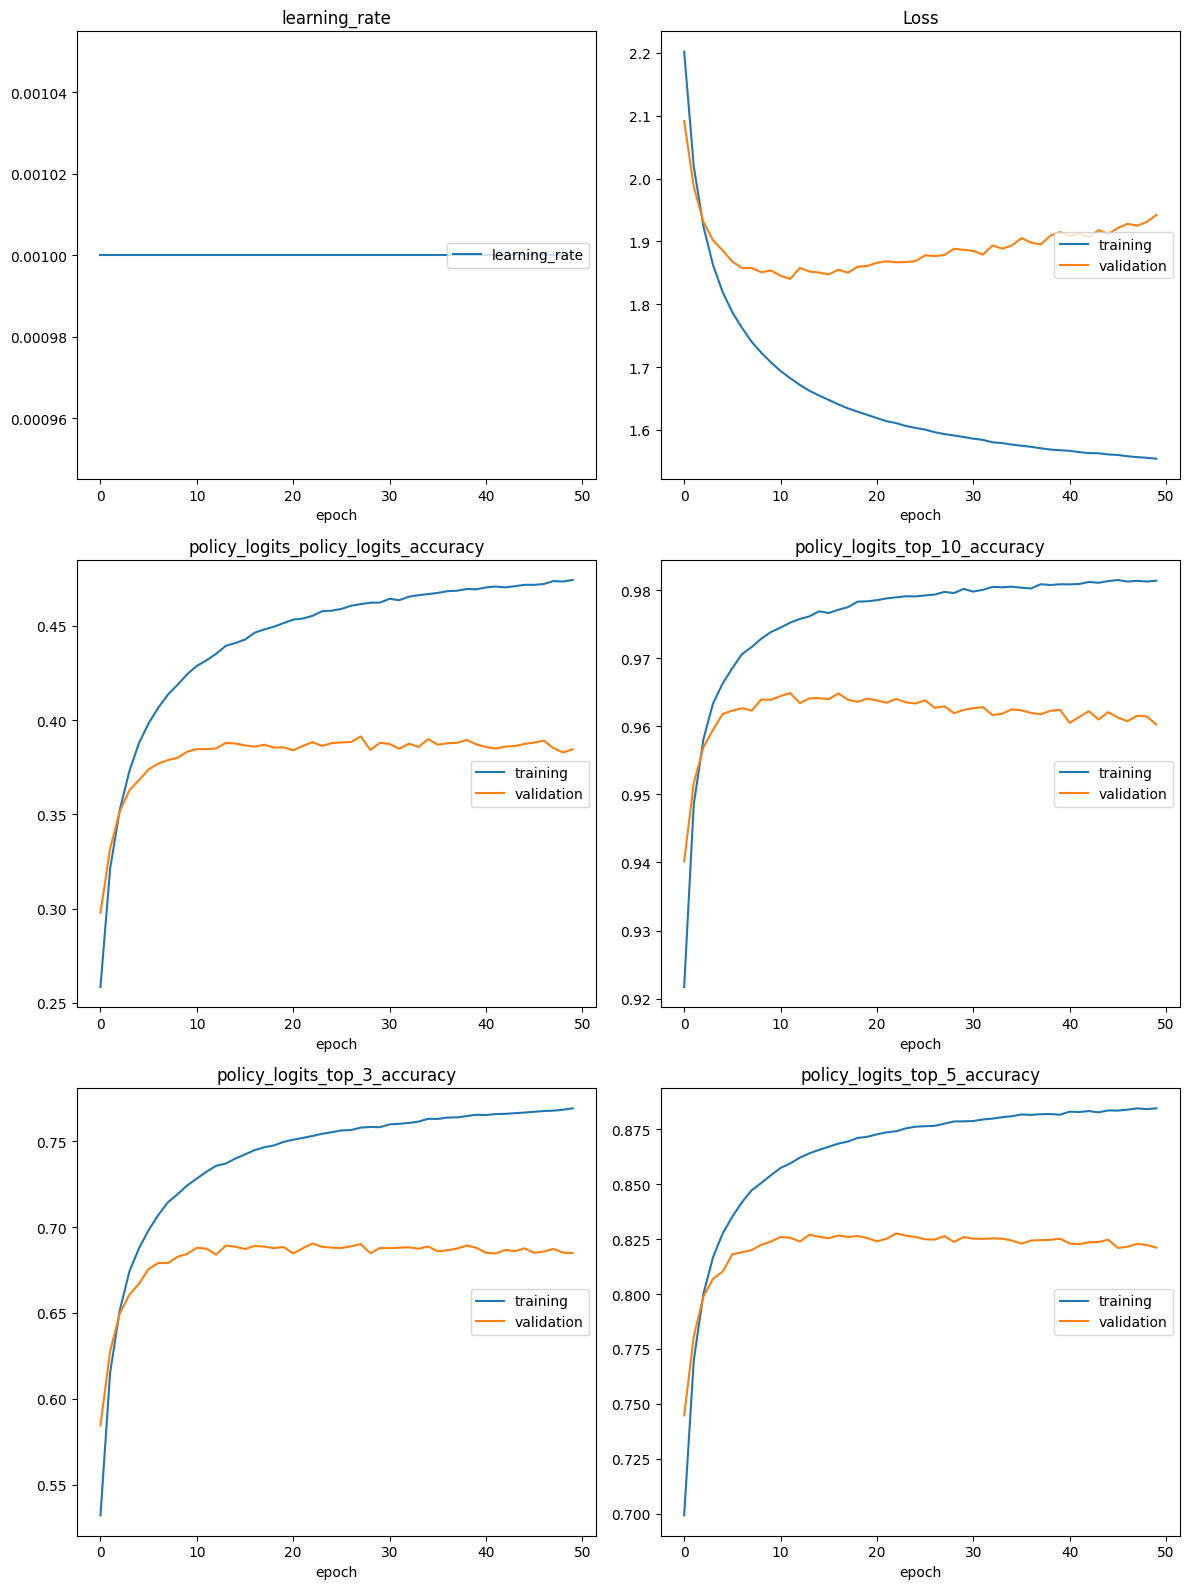

learning_rate
	learning_rate    	 (min:    0.001, max:    0.001, cur:    0.001)
Loss
	training         	 (min:    1.554, max:    2.202, cur:    1.554)
	validation       	 (min:    1.840, max:    2.091, cur:    1.942)
policy_logits_policy_logits_accuracy
	training         	 (min:    0.258, max:    0.474, cur:    0.474)
	validation       	 (min:    0.298, max:    0.391, cur:    0.385)
policy_logits_top_10_accuracy
	training         	 (min:    0.922, max:    0.981, cur:    0.981)
	validation       	 (min:    0.940, max:    0.965, cur:    0.960)
policy_logits_top_3_accuracy
	training         	 (min:    0.532, max:    0.769, cur:    0.769)
	validation       	 (min:    0.584, max:    0.691, cur:    0.685)
policy_logits_top_5_accuracy
	training         	 (min:    0.699, max:    0.885, cur:    0.885)
	validation       	 (min:    0.745, max:    0.828, cur:    0.821)
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 1.5542 - policy_logits_policy_logits_accuracy: 0.4743 - policy_logits_top_10_a

In [19]:
history = network.fit(
    x_train,
    [y_masked, y_value],
    batch_size=64,
    validation_batch_size=512,
    shuffle=True,  # déjà shufflé manuellement → évite la copie interne par epoch
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint, reduce_lr, PlotLossesKeras()]
)